In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/vibe_coding_combined_translated.csv")
df

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username,full_text_translated,needs_translation
0,1886192184808149383,2025-02-02 23:22:18+00:00,444,@karpathy me vibe coding and hope it can just ...,1886193454730137763,https://pbs.twimg.com/media/Gi0a82HaQAA97Q-.jpg,karpathy,en,NaN,0,5,10,https://x.com/Yuchenj_UW/status/18861934547301...,800854096219471872,Yuchenj_UW,@karpathy me vibe coding and hope it can just ...,False
1,1886196686709805486,2025-02-02 23:35:08+00:00,10,vibes capital meets vibe coding = greatest eco...,1886196686709805486,NaN,NaN,en,NaN,0,0,0,https://x.com/nikunj/status/1886196686709805486,30405893,nikunj,vibes capital meets vibe coding = greatest eco...,False
2,1886198988199600391,2025-02-02 23:44:17+00:00,3563,vibe coding https://t.co/1hHVMmunrw,1886198988199600391,https://pbs.twimg.com/media/Gi0f9fAWgAAgox6.jpg,NaN,en,NaN,18,35,191,https://x.com/IterIntellectus/status/188619898...,1655936149733654530,IterIntellectus,vibe coding https://t.co/1hHVMmunrw,False
3,1886203668619493715,2025-02-03 00:02:53+00:00,0,can attest. vibe coding is hella fun and borde...,1886203668619493715,NaN,NaN,en,NaN,0,0,0,https://x.com/kermankohli/status/1886203668619...,143624329,kermankohli,can attest. vibe coding is hella fun and borde...,False
4,1886204681766027415,2025-02-03 00:06:54+00:00,7,I have built a few app ideas in my spare time ...,1886204681766027415,NaN,NaN,en,NaN,0,0,0,https://x.com/luizfgparreira/status/1886204681...,2937425254,luizfgparreira,I have built a few app ideas in my spare time ...,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21392,2027533407245521272,2026-02-27 23:56:48+00:00,173,If you worried that everyone in the future wil...,2027533407245521272,NaN,NaN,en,NaN,2,25,5,https://x.com/neogoose_btw/status/202753340724...,1018840293901328384,neogoose_btw,If you worried that everyone in the future wil...,False
21393,2027533580868395390,2026-02-27 23:57:30+00:00,223,I wonder if Claude does a better job vibe codi...,2027533580868395390,NaN,NaN,en,NaN,3,10,7,https://x.com/deanwball/status/202753358086839...,30557408,deanwball,I wonder if Claude does a better job vibe codi...,False
21394,2027533965628707209,2026-02-27 23:59:01+00:00,1,"Hablando de Vibe Coding, en lugar de meter IA ...",2027533965628707209,NaN,NaN,es,NaN,0,1,0,https://x.com/diegofesc/status/202753396562870...,90892581,diegofesc,"Speaking of Vibe Coding, instead of putting AI...",False
21395,2027534089402913067,2026-02-27 23:59:31+00:00,725,Everyone is talking about the death of consume...,2027534089402913067,https://pbs.twimg.com/media/HCM5MvQbEAIgm2o.png,NaN,en,NaN,6,58,73,https://x.com/omooretweets/status/202753408940...,1399771783415308291,omooretweets,Everyone is talking about the death of consume...,False


In [ ]:
#count of conversation_id_str
df["conversation_id_str"].nunique()

21209

In [17]:
#count of unique user_id_str
df["user_id_str"].nunique()

14346

In [ ]:
#check distribution of languages using the "lang" column
df["lang"].value_counts()

,count
lang,
en,19230
ja,652
es,409
zh,337
pt,172
tr,145
fr,104
ar,60
in,41


/tmp/ipykernel_15334/1497833697.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_filtered['month_year'] = df_filtered['created_at'].dt.to_period('M')
/tmp/ipykernel_15334/1497833697.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_distribution.index, y=monthly_distribution.values, palette='viridis')


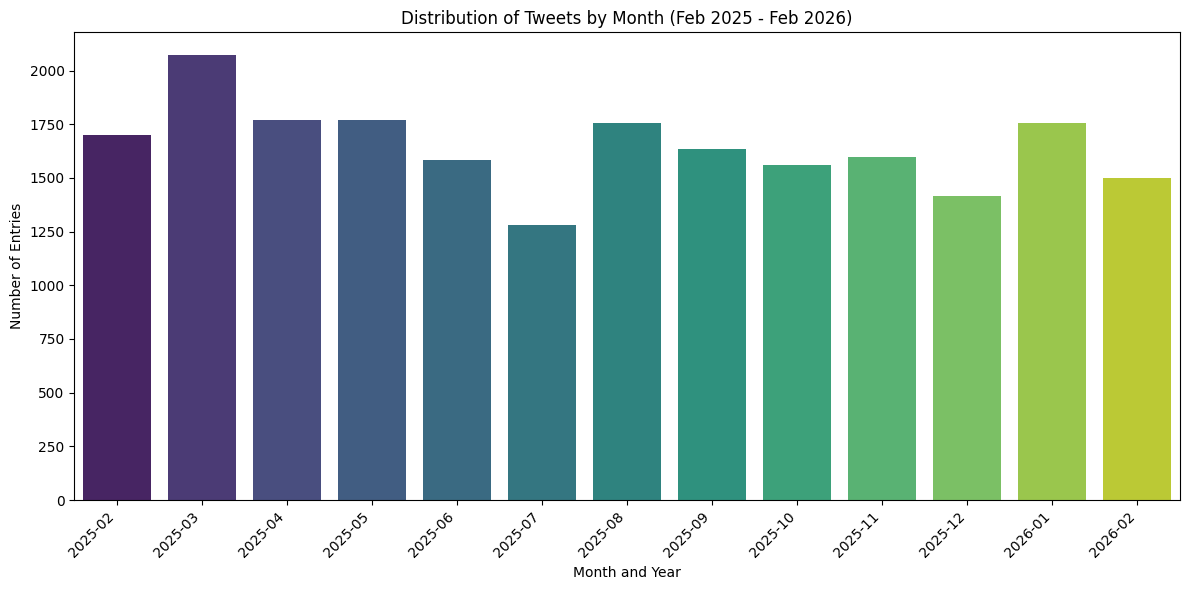

In [15]:
# Convert 'created_at' to datetime if not already converted
df['created_at'] = pd.to_datetime(df['created_at'])

# Define the date range for filtering
start_date = '2025-02-01'
end_date = '2026-02-28'

# Filter the DataFrame for the specified date range
df_filtered = df[(df['created_at'] >= start_date) & (df['created_at'] <= end_date)]

# Extract month and year for grouping
df_filtered['month_year'] = df_filtered['created_at'].dt.to_period('M')

# Count occurrences for each month-year combination
monthly_distribution = df_filtered['month_year'].value_counts().sort_index()

# Convert PeriodIndex to string for better plotting labels if needed
monthly_distribution.index = monthly_distribution.index.astype(str)

# Plot the distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_distribution.index, y=monthly_distribution.values, palette='viridis')
plt.title('Distribution of Tweets by Month (Feb 2025 - Feb 2026)')
plt.xlabel('Month and Year')
plt.ylabel('Number of Entries')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()